# Finance-Like Data and Results

This notebook turns the model-ready dataset into more finance-style outputs: forward returns, drawdowns, realized volatility, VIX shocks, event-study windows, and regime-level risk/return tables.


## Setup

Load the model-ready data, derive finance metrics, and create low/medium/high volatility regimes from absolute VIX moves. The enriched dataset is exported for later modeling or appendix tables.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.linear_model import LinearRegression

DATA_PATH = Path("../final_data")
ASSET_PATH = Path("assets/finance_results")
ASSET_PATH.mkdir(parents=True, exist_ok=True)

plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": "#f7f3ea",
    "axes.facecolor": "#fffaf0",
    "savefig.facecolor": "#f7f3ea",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#d8d0bf",
    "grid.alpha": 0.45,
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
})

ink = "#272522"
muted = "#6f6a60"
cream = "#f7f3ea"
panel = "#fffaf0"
blue = "#2f6f8f"
gold = "#d79a2b"
red = "#b33f3f"
teal = "#4d9b8f"
state_colors = {"Low": blue, "Medium": gold, "High": red}
heat_cmap = LinearSegmentedColormap.from_list("finance_heat", ["#fffaf0", "#f1c66a", "#c76348", "#7f2538"])

def polish(ax, title=None, subtitle=None):
    ax.set_facecolor(panel)
    ax.spines["left"].set_color("#c7bea9")
    ax.spines["bottom"].set_color("#c7bea9")
    ax.tick_params(axis="both", length=0, pad=6, colors="#3a3a3a")
    if title:
        ax.set_title(title, loc="left", color=ink, pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, ha="left", va="bottom", color=muted, fontsize=9.5)

def save_fig(fig, filename):
    fig.savefig(ASSET_PATH / filename, dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())


In [2]:
df = pd.read_csv(DATA_PATH / "model_ready_dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

trading_days = 252
finance_df = df.copy()
finance_df["abs_delta_vix"] = finance_df["delta_vix"].abs()
finance_df["sp500_log_return"] = np.log(finance_df["sp500_close"]).diff()
finance_df["sp500_cumulative_return"] = (1 + finance_df["sp500_return"]).cumprod() - 1
finance_df["sp500_running_max"] = finance_df["sp500_close"].cummax()
finance_df["sp500_drawdown"] = finance_df["sp500_close"] / finance_df["sp500_running_max"] - 1
finance_df["vix_zscore"] = (finance_df["vix_close"] - finance_df["vix_close"].mean()) / finance_df["vix_close"].std()
finance_df["vix_shock_flag"] = finance_df["abs_delta_vix"] >= finance_df["abs_delta_vix"].quantile(0.90)

for horizon in [1, 3, 5, 10]:
    finance_df[f"sp500_forward_return_{horizon}d"] = finance_df["sp500_close"].shift(-horizon) / finance_df["sp500_close"] - 1
    finance_df[f"vix_forward_change_{horizon}d"] = finance_df["vix_close"].shift(-horizon) - finance_df["vix_close"]

for window in [5, 10, 21]:
    finance_df[f"sp500_realized_vol_{window}d_ann"] = finance_df["sp500_return"].rolling(window).std() * np.sqrt(trading_days)

finance_df["vix_move_regime"] = pd.qcut(
    finance_df["abs_delta_vix"],
    q=[0, 1/3, 2/3, 1],
    labels=["Low", "Medium", "High"],
    duplicates="drop",
)
finance_df["risk_off_day"] = (finance_df["sp500_return"] < 0) & (finance_df["delta_vix"] > 0)

export_cols = [
    "date", "sp500_close", "sp500_return", "sp500_log_return", "sp500_cumulative_return",
    "sp500_drawdown", "vix_close", "delta_vix", "abs_delta_vix", "vix_zscore",
    "vix_move_regime", "vix_shock_flag", "risk_off_day",
] + [c for c in finance_df.columns if "forward" in c or "realized_vol" in c]

finance_df[export_cols].to_csv(DATA_PATH / "finance_enriched_dataset.csv", index=False)

print("Exported:", DATA_PATH / "finance_enriched_dataset.csv")
print("Date range:", finance_df["date"].min().date(), "to", finance_df["date"].max().date())
print("Rows:", len(finance_df))


Exported: ../final_data/finance_enriched_dataset.csv
Date range: 2025-05-27 to 2026-04-29
Rows: 183


## Market Snapshot

A compact market summary gives the project more finance vocabulary: total return, max drawdown, realized volatility, VIX range, and risk-off days.


In [3]:
market_snapshot = pd.DataFrame({
    "metric": [
        "S&P 500 total return",
        "S&P 500 max drawdown",
        "Average daily return",
        "Annualized realized volatility",
        "Return / vol ratio",
        "Average VIX",
        "Maximum VIX",
        "Largest absolute daily VIX move",
        "Risk-off day share",
    ],
    "value": [
        finance_df["sp500_close"].iloc[-1] / finance_df["sp500_close"].iloc[0] - 1,
        finance_df["sp500_drawdown"].min(),
        finance_df["sp500_return"].mean(),
        finance_df["sp500_return"].std() * np.sqrt(trading_days),
        finance_df["sp500_return"].mean() / finance_df["sp500_return"].std() * np.sqrt(trading_days),
        finance_df["vix_close"].mean(),
        finance_df["vix_close"].max(),
        finance_df["abs_delta_vix"].max(),
        finance_df["risk_off_day"].mean(),
    ],
})
market_snapshot["formatted"] = market_snapshot.apply(
    lambda r: f"{r['value']:.2%}" if "return" in r["metric"].lower() or "drawdown" in r["metric"].lower() or "volatility" in r["metric"].lower() or "share" in r["metric"].lower() or "ratio" in r["metric"].lower() else f"{r['value']:.2f}",
    axis=1,
)
market_snapshot[["metric", "formatted"]]


,metric,formatted
0,S&P 500 total return,20.51%
1,S&P 500 max drawdown,-9.10%
2,Average daily return,0.07%
3,Annualized realized volatility,12.47%
4,Return / vol ratio,143.39%
5,Average VIX,18.40
6,Maximum VIX,31.05
7,Largest absolute daily VIX move,5.74
8,Risk-off day share,34.97%


## Regime-Level Risk Table

This table asks a finance-style question: how do S&P 500 returns, drawdowns, and forward returns behave on low-, medium-, and high-VIX-move days?


In [4]:
def ann_vol(x):
    return x.std() * np.sqrt(trading_days)

def sharpe_like(x):
    return x.mean() / x.std() * np.sqrt(trading_days) if x.std() else np.nan

regime_summary = (
    finance_df
    .groupby("vix_move_regime", observed=True)
    .agg(
        days=("date", "count"),
        avg_sp500_return=("sp500_return", "mean"),
        ann_realized_vol=("sp500_return", ann_vol),
        sharpe_like=("sp500_return", sharpe_like),
        hit_rate=("sp500_return", lambda x: (x > 0).mean()),
        avg_vix=("vix_close", "mean"),
        avg_abs_delta_vix=("abs_delta_vix", "mean"),
        avg_next_1d_return=("sp500_forward_return_1d", "mean"),
        avg_next_5d_return=("sp500_forward_return_5d", "mean"),
        avg_next_10d_return=("sp500_forward_return_10d", "mean"),
        worst_day=("sp500_return", "min"),
    )
)
regime_summary.round(4)


,days,avg_sp500_return,ann_realized_vol,sharpe_like,hit_rate,avg_vix,avg_abs_delta_vix,avg_next_1d_return,avg_next_5d_return,avg_next_10d_return,worst_day
vix_move_regime,,,,,,,,,,,
Low,61,0.0009,0.0674,3.3565,0.6066,17.3118,0.2218,0.0016,0.0045,0.0079,-0.0099
Medium,61,0.0007,0.0823,2.1809,0.4918,17.5441,0.7566,0.0007,0.0052,0.0102,-0.0107
High,61,0.0005,0.1893,0.6907,0.5246,20.3584,2.3293,0.0009,0.0064,0.0125,-0.0271


## Price, VIX, and Drawdown View

This chart frames the sample like a market note: S&P 500 trend, VIX level, and drawdown pressure in one place.


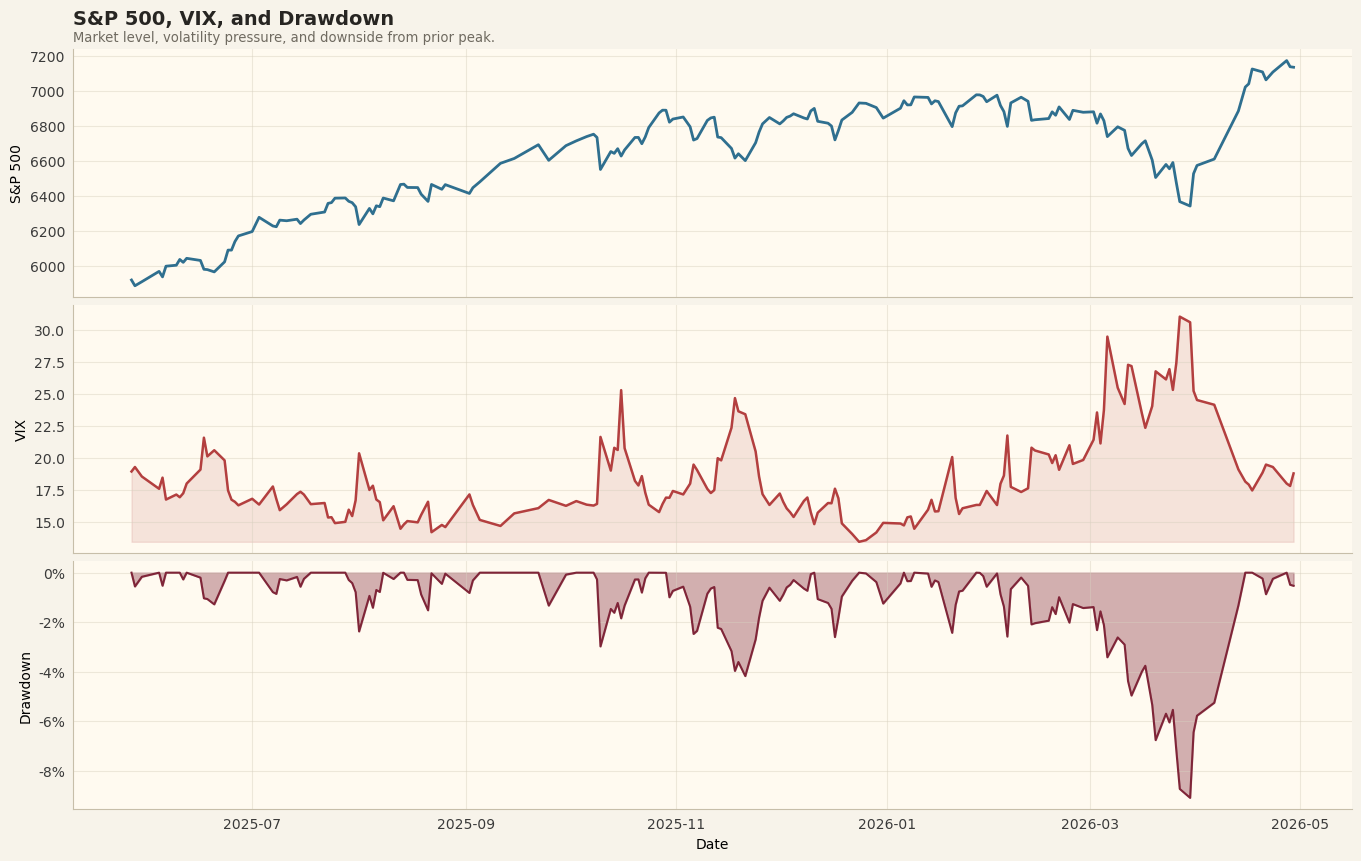

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13.5, 8.5), sharex=True, constrained_layout=True)
fig.patch.set_facecolor(cream)

axes[0].plot(finance_df["date"], finance_df["sp500_close"], color=blue, linewidth=2.0)
polish(axes[0], "S&P 500, VIX, and Drawdown", "Market level, volatility pressure, and downside from prior peak.")
axes[0].set_ylabel("S&P 500")

axes[1].plot(finance_df["date"], finance_df["vix_close"], color=red, linewidth=1.8)
axes[1].fill_between(finance_df["date"], finance_df["vix_close"], finance_df["vix_close"].min(), color=red, alpha=0.12)
polish(axes[1])
axes[1].set_ylabel("VIX")

axes[2].fill_between(finance_df["date"], finance_df["sp500_drawdown"], 0, color="#7f2538", alpha=0.35)
axes[2].plot(finance_df["date"], finance_df["sp500_drawdown"], color="#7f2538", linewidth=1.5)
polish(axes[2])
axes[2].set_ylabel("Drawdown")
axes[2].set_xlabel("Date")
axes[2].yaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")

save_fig(fig, "price_vix_drawdown_view.png")
plt.show()


## Forward Returns by VIX-Move Regime

This plot shows whether high VIX-move days are followed by different S&P 500 returns over 1-, 3-, 5-, and 10-day horizons.


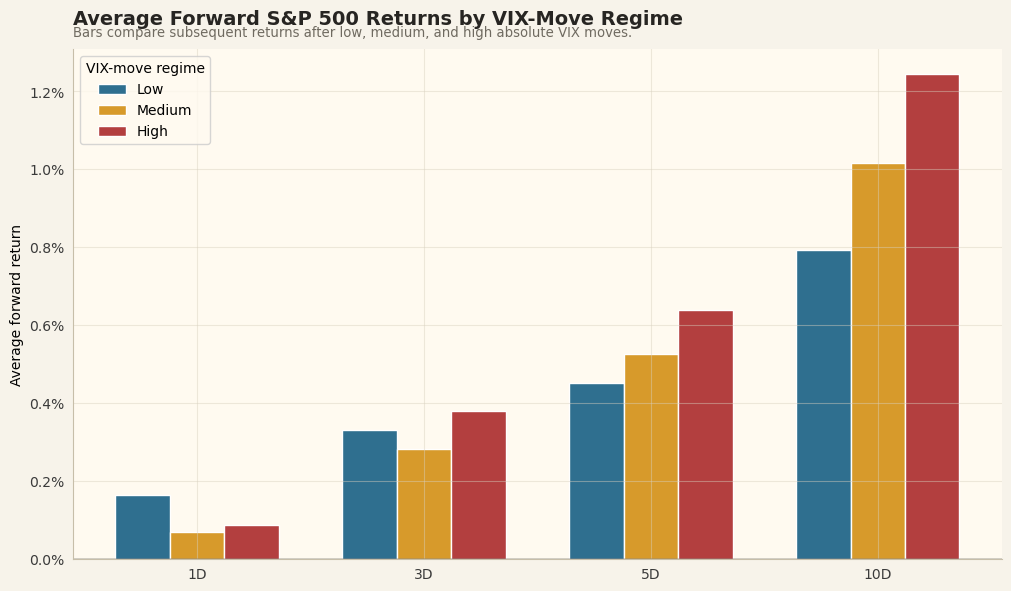

,1D,3D,5D,10D
vix_move_regime,,,,
Low,0.0016,0.0033,0.0045,0.0079
Medium,0.0007,0.0028,0.0052,0.0102
High,0.0009,0.0038,0.0064,0.0125


In [6]:
forward_cols = [f"sp500_forward_return_{h}d" for h in [1, 3, 5, 10]]
forward_summary = finance_df.groupby("vix_move_regime", observed=True)[forward_cols].mean()
forward_summary.columns = ["1D", "3D", "5D", "10D"]

fig, ax = plt.subplots(figsize=(10, 5.8), constrained_layout=True)
fig.patch.set_facecolor(cream)
x = np.arange(len(forward_summary.columns))
width = 0.24
for i, regime in enumerate(["Low", "Medium", "High"]):
    ax.bar(
        x + (i - 1) * width,
        forward_summary.loc[regime],
        width,
        label=regime,
        color=state_colors[regime],
        edgecolor="white",
        linewidth=1.0,
    )
ax.axhline(0, color=ink, linewidth=1)
ax.set_xticks(x, forward_summary.columns)
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.1%}")
ax.set_ylabel("Average forward return")
polish(ax, "Average Forward S&P 500 Returns by VIX-Move Regime", "Bars compare subsequent returns after low, medium, and high absolute VIX moves.")
ax.legend(title="VIX-move regime")
save_fig(fig, "forward_returns_by_regime.png")
plt.show()

forward_summary.round(4)


## VIX Shock Event Study

The event study averages S&P 500 cumulative returns around the largest VIX-move days. This is a more finance-native way to discuss what happens before and after volatility shocks.


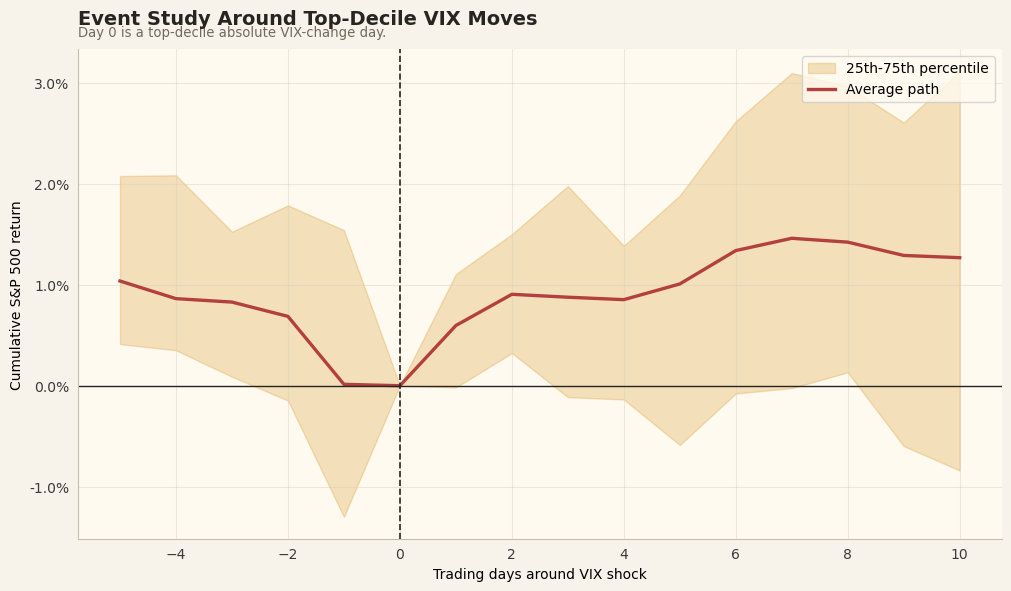

,event_day,abs_delta_vix,sp500_return
37,2025-08-01,3.66,-0.015992
38,2025-08-04,2.86,0.014737
65,2025-10-10,5.23,-0.027112
66,2025-10-13,2.63,0.015599
69,2025-10-16,4.67,-0.006294
70,2025-10-17,4.53,0.005271
93,2025-11-21,2.99,0.009823
94,2025-11-24,2.91,0.015467
128,2026-01-21,3.19,0.011588
138,2026-02-05,3.13,-0.012251


In [7]:
event_window_pre = 5
event_window_post = 10
shock_events = finance_df.loc[finance_df["vix_shock_flag"]].copy()
shock_events = shock_events.loc[
    (shock_events.index >= event_window_pre) &
    (shock_events.index <= len(finance_df) - event_window_post - 1)
]

paths = []
for event_idx in shock_events.index:
    window = finance_df.iloc[event_idx - event_window_pre:event_idx + event_window_post + 1].copy()
    rel_day = np.arange(-event_window_pre, event_window_post + 1)
    cumulative = (1 + window["sp500_return"]).cumprod()
    cumulative = cumulative / cumulative.iloc[event_window_pre] - 1
    paths.append(pd.Series(cumulative.to_numpy(), index=rel_day))

event_paths = pd.concat(paths, axis=1)
event_mean = event_paths.mean(axis=1)
event_p25 = event_paths.quantile(0.25, axis=1)
event_p75 = event_paths.quantile(0.75, axis=1)

fig, ax = plt.subplots(figsize=(10, 5.8), constrained_layout=True)
fig.patch.set_facecolor(cream)
ax.fill_between(event_mean.index, event_p25, event_p75, color=gold, alpha=0.28, label="25th-75th percentile")
ax.plot(event_mean.index, event_mean, color=red, linewidth=2.4, label="Average path")
ax.axvline(0, color=ink, linewidth=1.2, linestyle="--")
ax.axhline(0, color=ink, linewidth=1)
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.1%}")
ax.set_xlabel("Trading days around VIX shock")
ax.set_ylabel("Cumulative S&P 500 return")
polish(ax, "Event Study Around Top-Decile VIX Moves", "Day 0 is a top-decile absolute VIX-change day.")
ax.legend()
save_fig(fig, "vix_shock_event_study.png")
plt.show()

pd.DataFrame({"event_day": shock_events["date"].dt.date, "abs_delta_vix": shock_events["abs_delta_vix"], "sp500_return": shock_events["sp500_return"]}).head(10)


## VIX-Equity Leverage Relationship

Equity selloffs usually coincide with rising volatility. This scatter plot estimates that relationship directly in the sample.


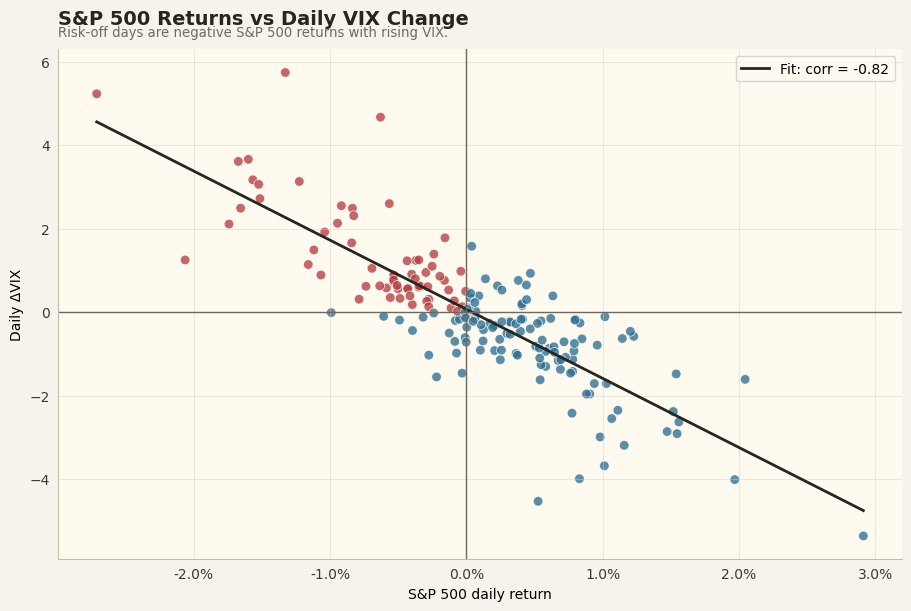

,correlation_sp500_return_delta_vix,delta_vix_per_1pct_sp500_return,intercept
0,-0.8246,-1.6552,0.0702


In [8]:
scatter_df = finance_df.dropna(subset=["sp500_return", "delta_vix"])
X = scatter_df[["sp500_return"]].to_numpy()
y = scatter_df["delta_vix"].to_numpy()
reg = LinearRegression().fit(X, y)
x_line = np.linspace(scatter_df["sp500_return"].min(), scatter_df["sp500_return"].max(), 100)
y_line = reg.predict(x_line.reshape(-1, 1))
correlation = scatter_df["sp500_return"].corr(scatter_df["delta_vix"])

fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
fig.patch.set_facecolor(cream)
colors = np.where(scatter_df["risk_off_day"], red, blue)
ax.scatter(scatter_df["sp500_return"], scatter_df["delta_vix"], c=colors, alpha=0.78, s=48, edgecolor="white", linewidth=0.6)
ax.plot(x_line, y_line, color=ink, linewidth=2.0, label=f"Fit: corr = {correlation:.2f}")
ax.axhline(0, color=muted, linewidth=1)
ax.axvline(0, color=muted, linewidth=1)
ax.xaxis.set_major_formatter(lambda x, pos: f"{x:.1%}")
ax.set_xlabel("S&P 500 daily return")
ax.set_ylabel("Daily ΔVIX")
polish(ax, "S&P 500 Returns vs Daily VIX Change", "Risk-off days are negative S&P 500 returns with rising VIX.")
ax.legend()
save_fig(fig, "sp500_vix_leverage_scatter.png")
plt.show()

pd.DataFrame({
    "correlation_sp500_return_delta_vix": [correlation],
    "delta_vix_per_1pct_sp500_return": [reg.coef_[0] * 0.01],
    "intercept": [reg.intercept_],
}).round(4)


## Stress-Day Table

These are the most finance-like individual observations: the largest VIX shocks, the same-day S&P move, forward S&P returns, and drawdown state.


In [9]:
stress_table = (
    finance_df
    .sort_values("abs_delta_vix", ascending=False)
    [[
        "date", "vix_close", "delta_vix", "abs_delta_vix", "sp500_return",
        "sp500_forward_return_1d", "sp500_forward_return_5d", "sp500_forward_return_10d",
        "sp500_drawdown", "vix_move_regime", "risk_off_day",
    ]]
    .head(15)
    .copy()
)
stress_table["date"] = stress_table["date"].dt.date
stress_table.round(4)


,date,vix_close,delta_vix,abs_delta_vix,sp500_return,sp500_forward_return_1d,sp500_forward_return_5d,sp500_forward_return_10d,sp500_drawdown,vix_move_regime,risk_off_day
155,2026-03-06,29.49,5.74,5.74,-0.0133,0.0083,-0.0060,-0.0272,-0.0342,High,True
170,2026-03-31,25.25,-5.36,5.36,0.0291,0.0072,0.0785,0.0989,-0.0645,High,False
65,2025-10-10,21.66,5.23,5.23,-0.0271,0.0156,0.0170,0.0365,-0.0298,High,True
69,2025-10-16,25.31,4.67,4.67,-0.0063,0.0053,0.0165,0.0292,-0.0185,High,True
70,2025-10-17,20.78,-4.53,4.53,0.0053,0.0107,0.0192,0.0264,-0.0133,High,False
139,2026-02-06,17.76,-4.01,4.01,0.0197,0.0047,-0.0128,-0.0061,-0.0066,High,False
156,2026-03-09,25.50,-3.99,3.99,0.0083,-0.0030,-0.0118,-0.0300,-0.0262,High,False
160,2026-03-16,23.51,-3.68,3.68,0.0101,0.0025,-0.0213,-0.0255,-0.0400,High,False
37,2025-08-01,20.38,3.66,3.66,-0.0160,0.0147,0.0243,0.0338,-0.0238,High,True
168,2026-03-27,31.05,3.61,3.61,-0.0167,-0.0039,0.0812,0.1092,-0.0874,High,True


## Takeaway

These finance-derived fields let the project talk in market terms: realized volatility, forward returns, drawdowns, shock events, hit rates, and volatility-equity co-movement. They can be merged back into the NLP/regime models or used as standalone descriptive results.
